In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

import zipfile
import os

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv.zip to IMDb Movies India.csv (1).zip


In [ ]:
zip_file = "IMDb Movies India.csv.zip"
with zipfile.ZipFile(zip_file,'r') as zip_ref:
  zip_ref.extractall("movie_dataset")
print("Movie dataset extract successfully !")
os.listdir("movie_dataset")

Movie dataset extract successfully !


['IMDb Movies India.csv']

In [ ]:
df = pd.read_csv(
    "movie_dataset/IMDb Movies India.csv",
    encoding = "latin1"
)
print("dataset load successfully")

dataset load successfully


In [ ]:
df.head(20)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [ ]:
df.shape

(15509, 10)

In [ ]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
df.describe(include="all")

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Mamta,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_df=  pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})
missing_df.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Duration,8269,53.317429
Rating,7590,48.939326
Votes,7589,48.932878
Actor 3,3144,20.272100
Actor 2,2384,15.371720
Genre,1877,12.102650
Actor 1,1617,10.426204
Year,528,3.404475
Director,525,3.385131
Name,0,0.000000


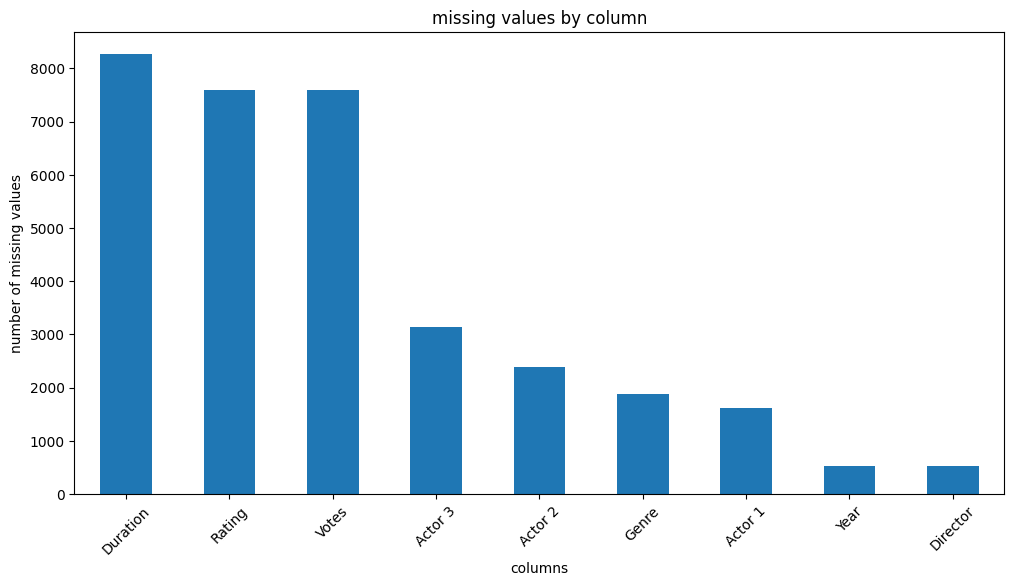

In [ ]:
plt.figure(figsize=(12,6))
missing_values[missing_values > 0].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("missing values by column")
plt.xlabel("columns")
plt.ylabel("number of missing values")
plt.xticks(rotation=45)
plt.show()


In [ ]:
data= df.copy()

In [ ]:
categorical_columns = [
    "Name",
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]
for col in categorical_columns:
   data[col]= data[col].fillna("Unknown")

In [ ]:
data["Year_num"] = pd.to_numeric(
    data["Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

In [ ]:
data[["Year", "Year_num"]].head()

,Year,Year_num
0,NaN,NaN
1,(2019),2019.0
2,(2021),2021.0
3,(2019),2019.0
4,(2010),2010.0


In [ ]:
data["Duration_num"] = pd.to_numeric(
    data["Duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

In [ ]:
data[["Duration", "Duration_num"]].head()


,Duration,Duration_num
0,NaN,NaN
1,109 min,109.0
2,90 min,90.0
3,110 min,110.0
4,105 min,105.0


In [ ]:
data["Votes_num"] = pd.to_numeric(
    data["Votes"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

In [ ]:
data[["Votes", "Votes_num"]].head()

,Votes,Votes_num
0,NaN,NaN
1,8,8.0
2,NaN,NaN
3,35,35.0
4,NaN,NaN


In [ ]:
data["Rating"] = pd.to_numeric(
    data["Rating"],
    errors="coerce"
)

In [ ]:
data = data.dropna(subset=["Rating"])

data.reset_index(drop=True, inplace=True)

print("Rows after cleaning:", len(data))

Rows after cleaning: 7919


In [ ]:
data.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Year_num,Duration_num,Votes_num
0,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,2019.0,109.0,8.0
1,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,2019.0,110.0,35.0
2,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,1997.0,147.0,827.0
3,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,2005.0,142.0,1086.0
4,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,2012.0,82.0,326.0
5,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon,2014.0,116.0,11.0
6,1:1.6 An Ode to Lost Love,(2004),96 min,Drama,6.2,17,Madhu Ambat,Rati Agnihotri,Gulshan Grover,Atul Kulkarni,2004.0,96.0,17.0
7,1:13:7 Ek Tera Saath,(2016),120 min,Horror,5.9,59,Arshad Siddiqui,Pankaj Berry,Anubhav Dhir,Hritu Dudani,2016.0,120.0,59.0
8,100 Days,(1991),161 min,"Horror, Romance, Thriller",6.5,983,Partho Ghosh,Jackie Shroff,Madhuri Dixit,Javed Jaffrey,1991.0,161.0,983.0
9,100% Love,(2012),166 min,"Comedy, Drama, Romance",5.7,512,Rabi Kinagi,Jeet,Koyel Mallick,Sujoy Ghosh,2012.0,166.0,512.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          7919 non-null   object 
 1   Year          7919 non-null   object 
 2   Duration      5851 non-null   object 
 3   Genre         7919 non-null   object 
 4   Rating        7919 non-null   float64
 5   Votes         7919 non-null   object 
 6   Director      7919 non-null   object 
 7   Actor 1       7919 non-null   object 
 8   Actor 2       7919 non-null   object 
 9   Actor 3       7919 non-null   object 
 10  Year_num      7919 non-null   float64
 11  Duration_num  5851 non-null   float64
 12  Votes_num     7919 non-null   float64
dtypes: float64(4), object(9)
memory usage: 804.4+ KB


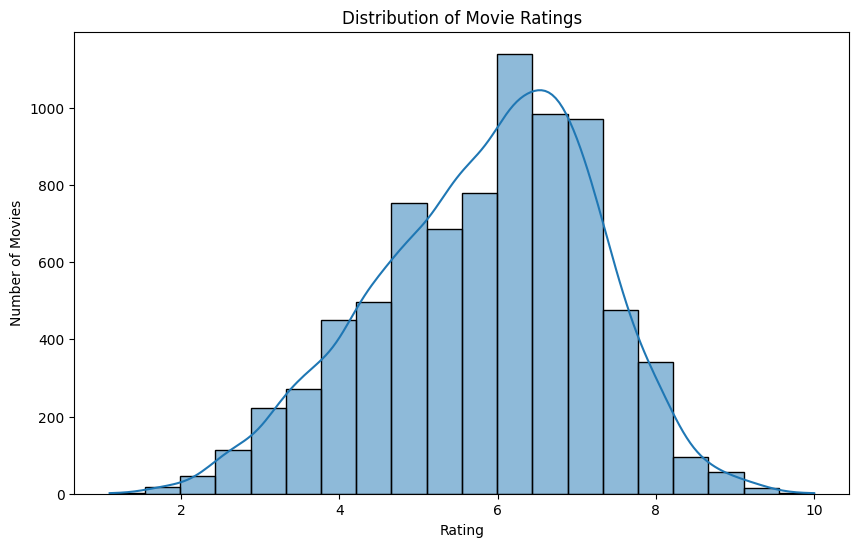

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

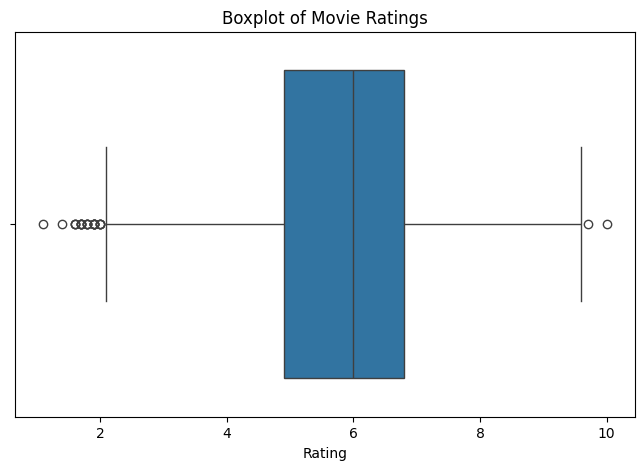

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=data["Rating"]
)

plt.title("Boxplot of Movie Ratings")
plt.xlabel("Rating")

plt.show()

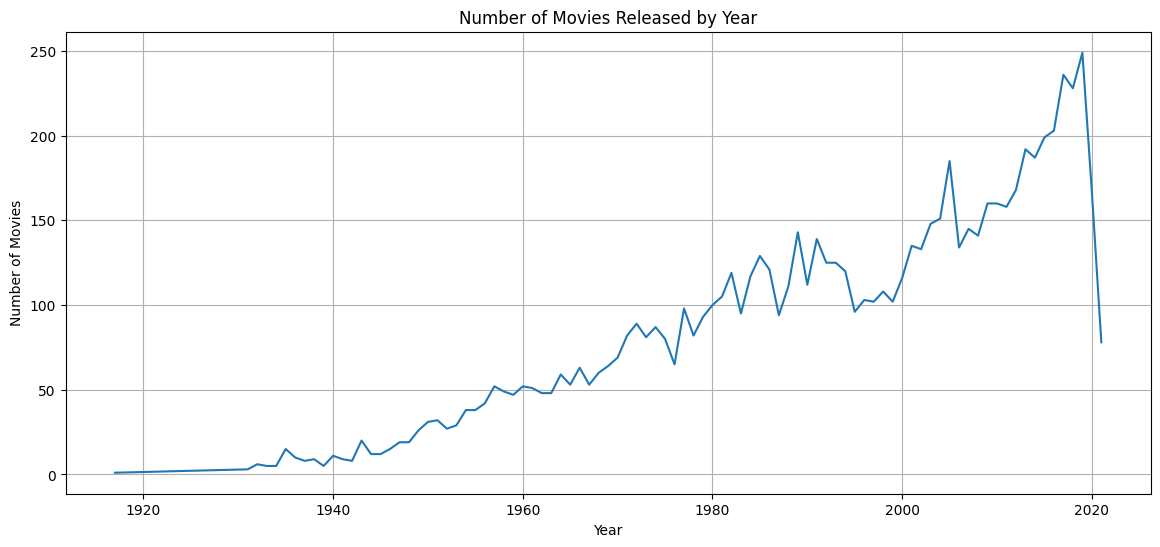

In [ ]:
year_counts = data["Year_num"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.grid(True)
plt.show()

In [ ]:
genre_counts = (
    data["Genre"]
    .value_counts()
    .head(10)
)

print(genre_counts)

Genre
Drama                     1177
Drama, Romance             447
Action, Crime, Drama       417
Action                     417
Drama, Family              291
Action, Drama              271
Comedy                     259
Comedy, Drama              239
Romance                    234
Comedy, Drama, Romance     213
Name: count, dtype: int64


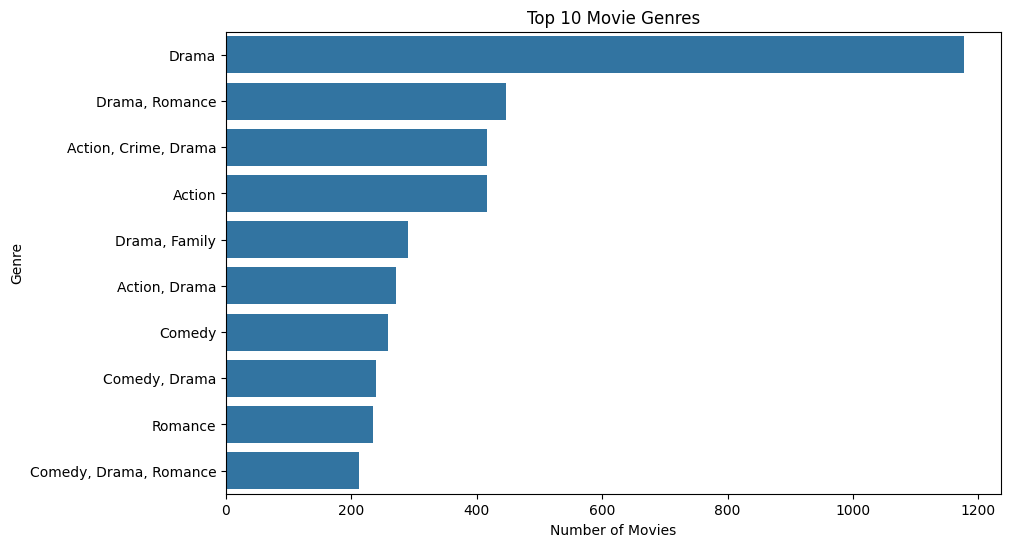

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

In [ ]:
genre_rating = (
    data.groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(genre_rating)

Genre
History, Romance                  9.40
Documentary, Family, History      9.30
Documentary, Music                8.90
Documentary, Biography, Music     8.80
Documentary, Sport                8.60
Animation, Comedy, Family         8.30
Biography, Family                 8.30
Documentary, Thriller             8.25
Documentary, Biography, Family    8.25
Documentary, Biography, Sport     8.20
Name: Rating, dtype: float64


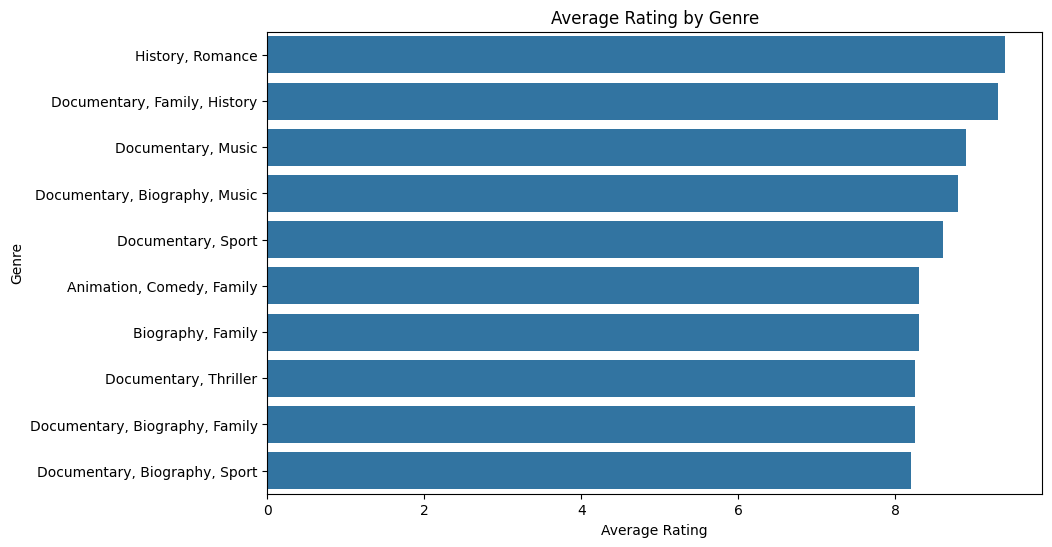

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_rating.values,
    y=genre_rating.index
)

plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

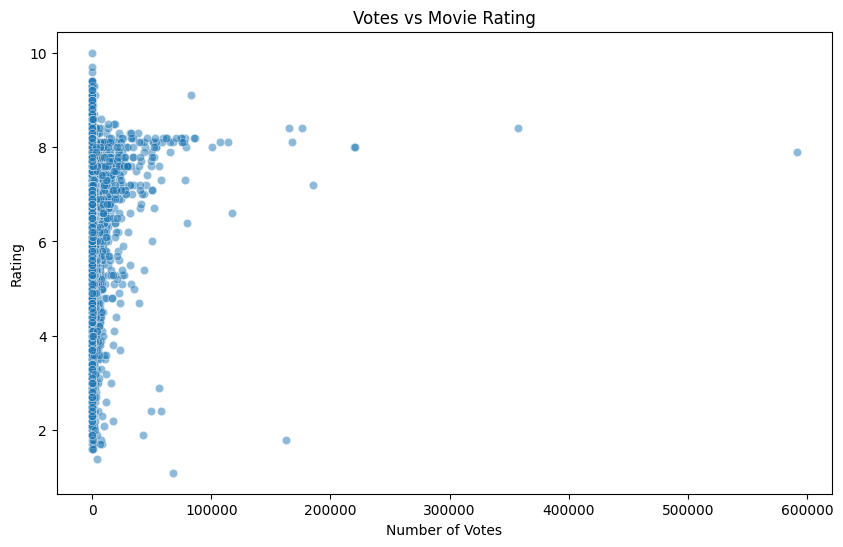

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Votes_num",
    y="Rating",
    alpha=0.5
)

plt.title("Votes vs Movie Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")

plt.show()

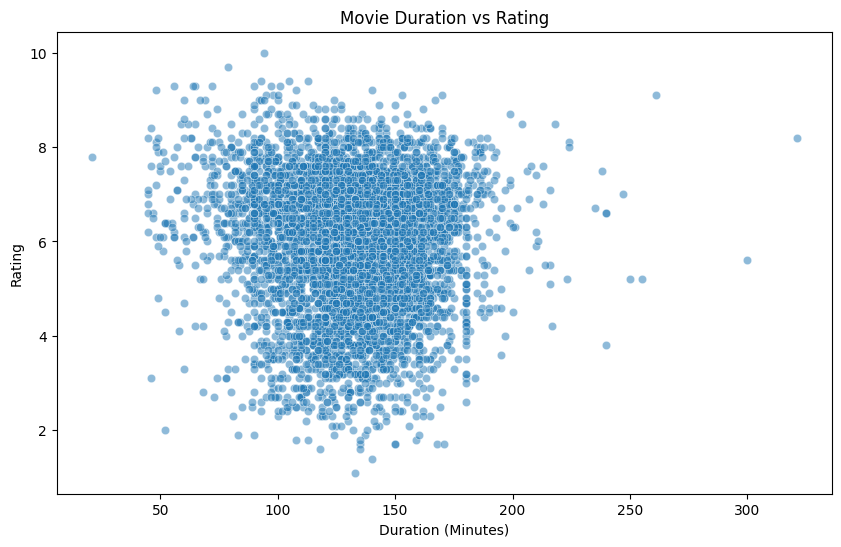

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Duration_num",
    y="Rating",
    alpha=0.5
)

plt.title("Movie Duration vs Rating")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Rating")

plt.show()

In [ ]:
numeric_data = data[
    [
        "Year_num",
        "Duration_num",
        "Votes_num",
        "Rating"
    ]
]

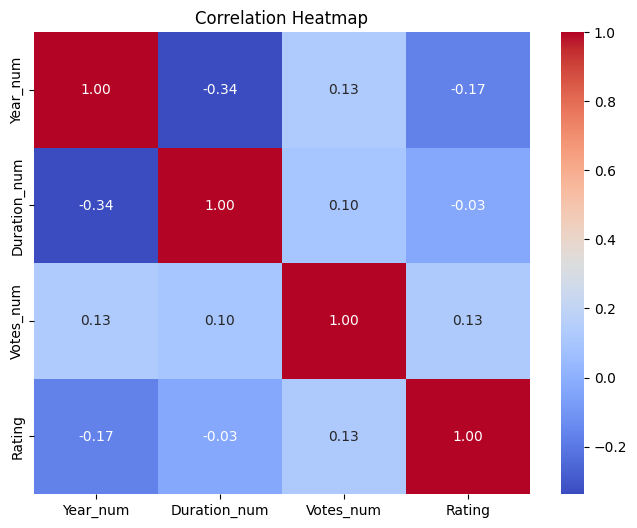

In [ ]:
correlation = numeric_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
features = [
    "Year_num",
    "Duration_num",
    "Votes_num",
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

X = data[features]

y = data["Rating"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 8)
Testing data: (1584, 8)


In [ ]:
numeric_features = [
    "Year_num",
    "Duration_num",
    "Votes_num"
]

categorical_features = [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [ ]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=2
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [ ]:
linear_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained!")

Linear Regression model trained!


In [ ]:
linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:10])

[5.01115893 5.7463668  4.29050607 6.65402451 4.68075128 5.46153535
 7.24712991 3.42146257 5.51026174 5.98840397]


In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 1.1511
RMSE : 1.4841
R²   : -0.1847


In [ ]:
ridge_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        Ridge(alpha=10.0)
    )
])

ridge_model.fit(
    X_train,
    y_train
)

print("Ridge Regression model trained!")

Ridge Regression model trained!


In [ ]:
ridge_predictions = ridge_model.predict(X_test)

print(ridge_predictions[:10])

[5.06147309 5.68944927 5.14231849 6.10873893 4.50578056 5.16852369
 6.04429717 5.47784081 6.08052195 5.97660017]


In [ ]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression Results")
print("-----------------------")
print(f"MAE  : {ridge_mae:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Results
-----------------------
MAE  : 0.9136
RMSE : 1.1632
R²   : 0.2723


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.151094,1.484112,-0.184731
1,Ridge Regression,0.913619,1.163181,0.272252


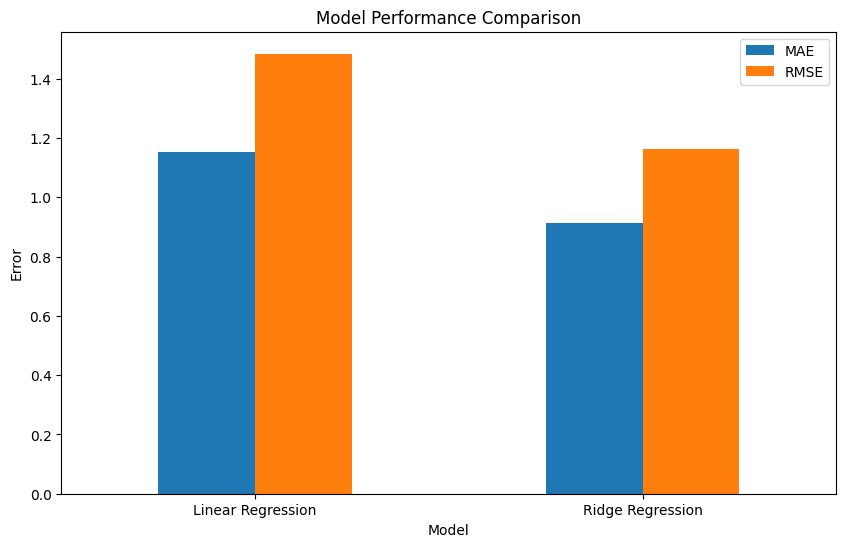

In [ ]:
results.set_index("Model")[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

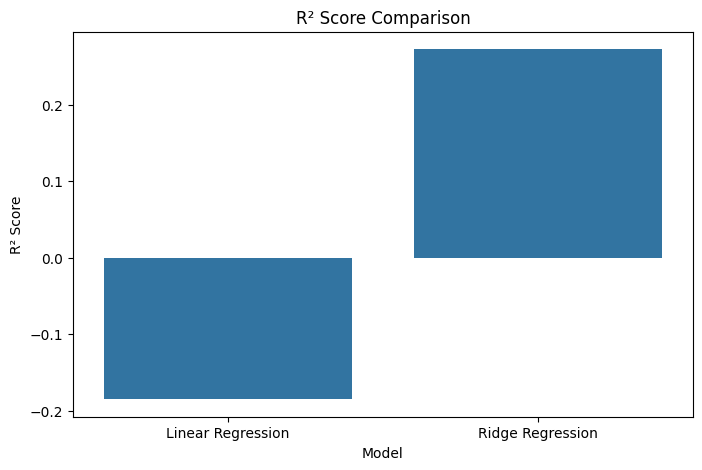

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")

plt.show()

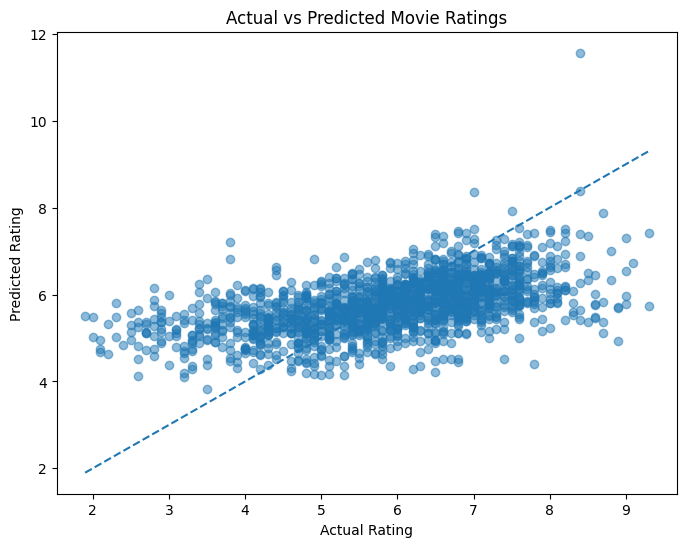

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title(
    "Actual vs Predicted Movie Ratings"
)

plt.show()

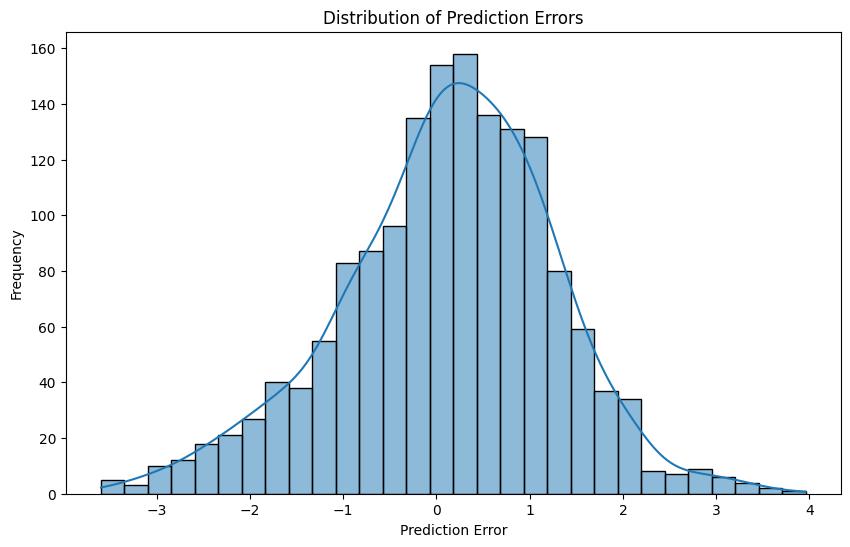

In [ ]:
errors = y_test - ridge_predictions

plt.figure(figsize=(10, 6))

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [ ]:
new_movie = pd.DataFrame({
    "Year_num": [2026],
    "Duration_num": [130],
    "Votes_num": [1000],
    "Genre": ["Drama"],
    "Director": ["Unknown Director"],
    "Actor 1": ["Actor A"],
    "Actor 2": ["Actor B"],
    "Actor 3": ["Actor C"]
})

In [ ]:
predicted_rating = ridge_model.predict(
    new_movie
)[0]

predicted_rating = np.clip(
    predicted_rating,
    0,
    10
)

print(
    f"Predicted Movie Rating: {predicted_rating:.2f}/10"
)

Predicted Movie Rating: 5.71/10


In [ ]:
new_movies = pd.DataFrame({
    "Year_num": [2026, 2025, 2024],
    "Duration_num": [130, 145, 120],
    "Votes_num": [1000, 5000, 2500],
    "Genre": ["Drama", "Action", "Comedy"],
    "Director": [
        "Unknown Director",
        "Unknown Director",
        "Unknown Director"
    ],
    "Actor 1": ["Actor A", "Actor B", "Actor C"],
    "Actor 2": ["Actor D", "Actor E", "Actor F"],
    "Actor 3": ["Actor G", "Actor H", "Actor I"]
})

predictions = ridge_model.predict(new_movies)

predictions = np.clip(
    predictions,
    0,
    10
)

new_movies["Predicted Rating"] = predictions

new_movies

,Year_num,Duration_num,Votes_num,Genre,Director,Actor 1,Actor 2,Actor 3,Predicted Rating
0,2026,130,1000,Drama,Unknown Director,Actor A,Actor D,Actor G,5.708557
1,2025,145,5000,Action,Unknown Director,Actor B,Actor E,Actor H,4.885096
2,2024,120,2500,Comedy,Unknown Director,Actor C,Actor F,Actor I,5.380828


## Conclusion

In this project, we developed a Machine Learning model to predict movie ratings using historical IMDb movie data.

The project included several important stages such as:

- Data collection and loading
- Data cleaning
- Handling missing values
- Feature engineering
- Exploratory Data Analysis
- Data visualization
- Categorical feature encoding
- Train-test splitting
- Regression modeling
- Model evaluation
- Movie rating prediction

The main features used for prediction were movie year, duration, number of votes, genre, director, and actors.

Linear Regression and Ridge Regression were tested and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The final model can estimate a movie's rating based on its available features. However, movie ratings are subjective and can depend on many factors that are not present in the dataset. Therefore, the model's prediction should be considered an estimate rather than an exact rating.